In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
data_path=Path('data/dataset_clean.csv')
df=pd.read_csv(data_path)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89740 non-null  str    
 1   artists           89740 non-null  str    
 2   album_name        89740 non-null  str    
 3   track_name        89740 non-null  str    
 4   popularity        89740 non-null  int64  
 5   duration_ms       89740 non-null  int64  
 6   explicit          89740 non-null  bool   
 7   danceability      89740 non-null  float64
 8   energy            89740 non-null  float64
 9   key               89740 non-null  int64  
 10  loudness          89740 non-null  float64
 11  mode              89740 non-null  int64  
 12  speechiness       89740 non-null  float64
 13  acousticness      89740 non-null  float64
 14  instrumentalness  89740 non-null  float64
 15  liveness          89740 non-null  float64
 16  valence           89740 non-null  float64
 17  temp

In [4]:
df.shape

(89740, 20)

In [5]:
print(df['valence'].unique())
print(df['valence'].value_counts())

[0.715   0.267   0.12    ... 0.00271 0.00984 0.00312]
valence
0.96100    249
0.96200    186
0.00000    176
0.96300    171
0.32400    162
          ... 
0.02510      1
0.01280      1
0.00271      1
0.00984      1
0.00312      1
Name: count, Length: 1790, dtype: int64


In [6]:
df['valence_cat']=pd.qcut(df['valence'],q=6,labels=['Angry','Depressed','Sad','Happy','Cheerful','Euphoric'])
print(df['valence_cat'].value_counts())

valence_cat
Angry        15024
Happy        15021
Depressed    14943
Sad          14921
Cheerful     14920
Euphoric     14911
Name: count, dtype: int64


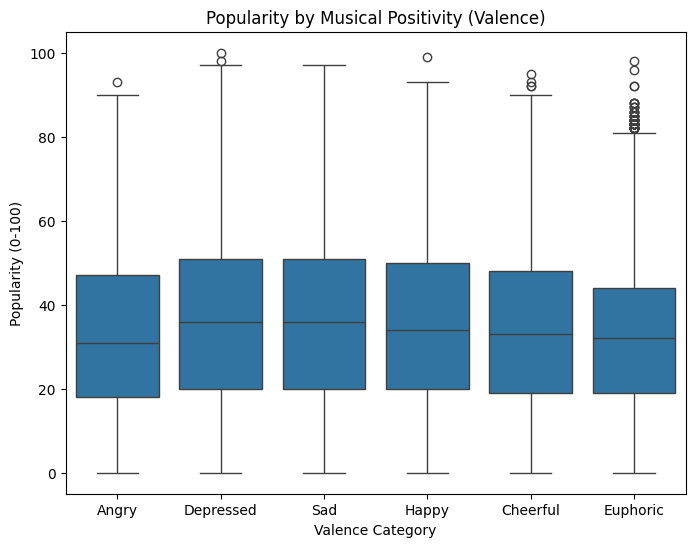

In [7]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='valence_cat',y='popularity')
plt.title('Popularity by Musical Positivity (Valence)')
plt.xlabel('Valence Category')
plt.ylabel('Popularity (0-100)')
df=df.drop(columns='valence_cat')

In [8]:
#Major is represented by 1 and minor is 0
df['popularity'].sort_values(ascending=False)

18906    100
45781     99
18913     98
57108     98
57110     97
        ... 
19892      0
10970      0
43309      0
10924      0
43311      0
Name: popularity, Length: 89740, dtype: int64

In [9]:
popularity_threshold=df['popularity'].quantile(0.90)
top10_df=df[df['popularity']>=popularity_threshold]


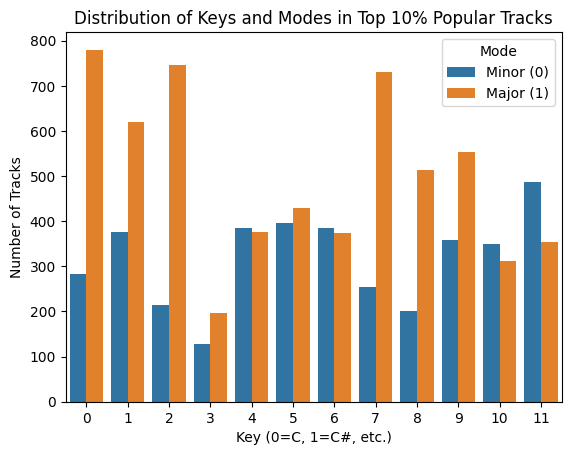

In [10]:
sns.countplot(data=top10_df,x='key',hue='mode')
plt.title('Distribution of Keys and Modes in Top 10% Popular Tracks')
plt.xlabel('Key (0=C, 1=C#, etc.)')
plt.ylabel('Number of Tracks')
plt.legend(title='Mode', labels=['Minor (0)', 'Major (1)'])
plt.show()

## Genre


In [11]:
genres = ['classical', 'heavy-metal', 'pop', 'hip-hop', 'world-music', 'techno']
features = ['danceability', 'energy', 'acousticness', 'valence']
filtered_df = df[df['track_genre'].isin(genres)]
genre_stats = filtered_df.groupby('track_genre')[features].mean().reset_index()
print(genre_stats)

   track_genre  danceability    energy  acousticness   valence
0    classical      0.385988  0.196554      0.919725  0.392003
1  heavy-metal      0.428339  0.874034      0.014997  0.388258
2      hip-hop      0.730052  0.695139      0.197945  0.552882
3          pop      0.580589  0.578505      0.402815  0.476947
4       techno      0.682798  0.777418      0.055787  0.333679
5  world-music      0.413944  0.535216      0.297415  0.251194


In [ ]:
melted_stats=pd.melt(genre_stats, id_vars=['track_genre'],value_vars=features,var_name='audio_feature',value_name='average_score')
fig=px.line_polar(melted_stats,r='average_score',theta='audio_feature',color='track_genre',line_close=True,title="Audio Feature Fingerprints by Genre")
fig.update_traces(fill='toself', opacity=0.6)
fig.update_layout(polar=dict(radialaxis=dict(visible=True,range=[0,1])))
fig.show()

## Correlations between variables

In [13]:
numeric_features = df.select_dtypes(include='number').drop(columns=['Unnamed: 0'], errors='ignore')

In [1]:
plt.figure(figsize=(10,8))
sns.heatmap(data=numeric_features.corr(),annot=True,cmap='coolwarm',fmt='.2f',vmin=-1,vmax=1,center=0,square=True,linewidths=.5)
plt.show()

NameError: name 'plt' is not defined

## Loudness and energy

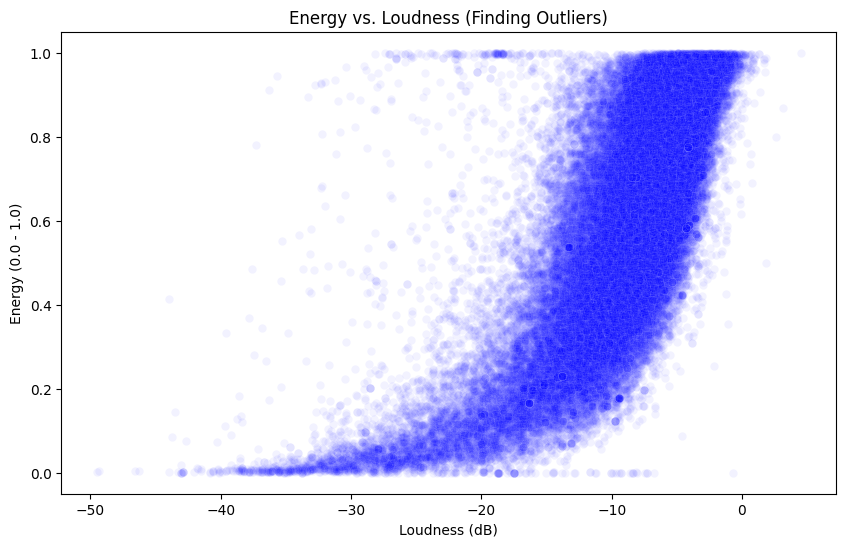

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='loudness',y='energy',alpha=0.05,color='blue')
plt.title('Energy vs. Loudness (Finding Outliers)')
plt.xlabel('Loudness (dB)')
plt.ylabel('Energy (0.0 - 1.0)')
plt.show()

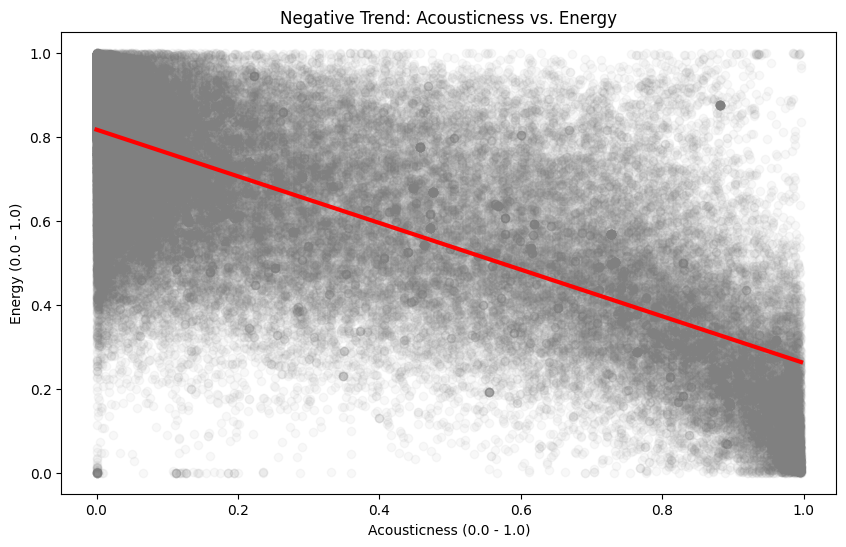

In [16]:
plt.figure(figsize=(10,6))
sns.regplot(data=df,x='acousticness',y='energy',scatter_kws={'alpha': 0.05, 'color': 'gray'}, line_kws={'color': 'red', 'linewidth': 3})
plt.title('Negative Trend: Acousticness vs. Energy')
plt.xlabel('Acousticness (0.0 - 1.0)')
plt.ylabel('Energy (0.0 - 1.0)')
plt.show()

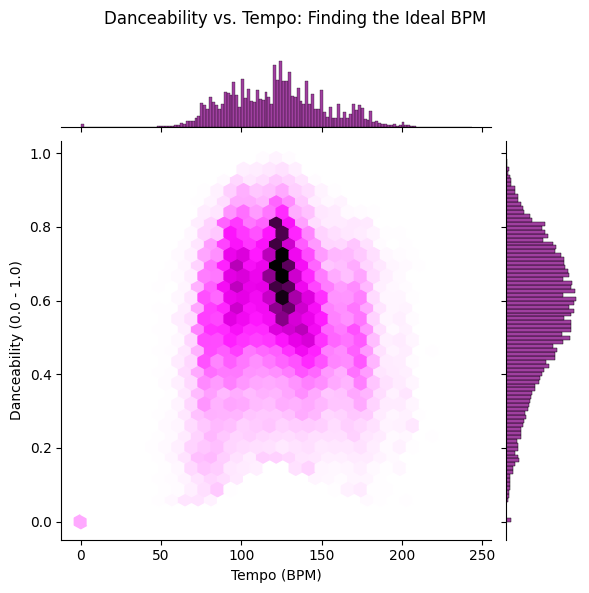

In [17]:
g = sns.jointplot(data=df, x='tempo', y='danceability', kind='hex', color='purple', gridsize=30)

g.figure.subplots_adjust(top=0.9) 
g.figure.suptitle('Danceability vs. Tempo: Finding the Ideal BPM')
g.ax_joint.set_xlabel('Tempo (BPM)')
g.ax_joint.set_ylabel('Danceability (0.0 - 1.0)')

plt.show()